In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv("height-weight.csv")
df.head()
# see it has one input feature and one Output feature so simple linear regression 

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


# it is simple Dataset so we wont be doing feature engineering and EDA stuff as this is Basic Data set for begineers and Learning 

Text(0, 0.5, 'Height')

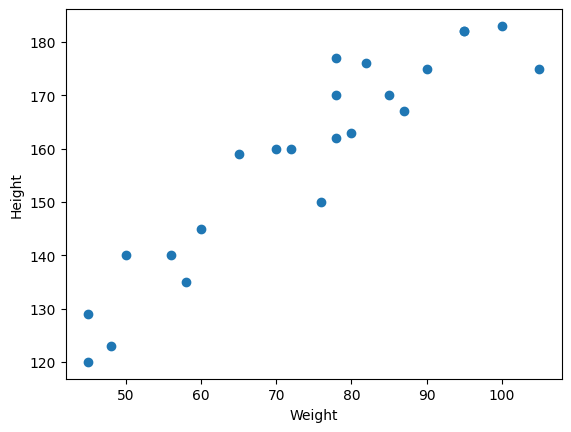

In [3]:
#scatter plot to see Co-relation 

plt.scatter(df["Weight"], df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")

In [4]:
#see Corelation using corr
df.corr()

# see Wight x Height .. corelation is 0.93 very close to 1 ( so highly positive co-related )

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


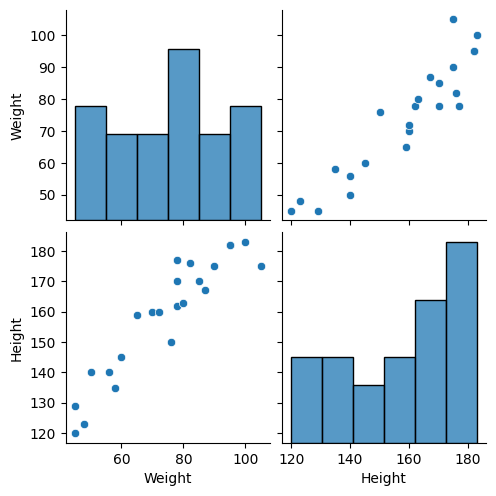

In [5]:
import seaborn as sns
sns.pairplot(df)

--
# Step 1: 

    * Divide Featre into INDependent/Input (X) and Dependent/Output (Y)*

In [6]:
x = df["Weight"]
x  # X that is Created is a Series 

## IMP
## Independent Feature Should be in the form DataFrame or 2D Array 

0      45
1      58
2      48
3      60
4      70
5      78
6      80
7      90
8      95
9      78
10     82
11     95
12    105
13    100
14     85
15     78
16     50
17     65
18     76
19     87
20     45
21     56
22     72
Name: Weight, dtype: int64

In [7]:
np.array(x).shape

# it is One 1D array as in shape ( row, col ) but here there is no col so 1D array
# also x is a series not Dataframe 
# 
# avoid these always make sure that X is in the form of Data Frame not Series  

(23,)

___

# Rule 

    Independent Feature must in the form of Data frame or 2D array 
    


In [8]:
X = df[['Weight']]  # Use double braket
type(X) 

# now its in the form of DF

pandas.DataFrame

In [9]:
X.head(3)

,Weight
0,45
1,58
2,48


___ 
    Dependent Feature Y could be Series or 1D 

In [10]:
Y = df["Height"]
type(Y)

pandas.Series

___ 
    so X Independent Feature Must be dataframe or 2D
    Y depenedent Feature could be series or 1D 

---

given below

In [11]:
X = df[['Weight']] # Independent Feature 
Y = df['Height']  # Dependent Feature    

# See above for Explanation

---
---
# Step 2:

### Train Test Split 

    Train Data will be used to Train Model 
    Test Data will be Used to Test Model 


# 2. Basic Syntax

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Here:

* `X` = Features (input variables)
* `y` = Labels/targets (output variables)

The function returns:

| Variable  | Meaning           |
| --------- | ----------------- |
| `X_train` | Training features |
| `X_test`  | Testing features  |
| `y_train` | Training labels   |
| `y_test`  | Testing labels    |

---

## Why do we split?

Suppose you have student data:

| Hours | Marks |
| ----- | ----- |
| 2     | 40    |
| 3     | 50    |
| 4     | 60    |
| 5     | 70    |
| 6     | 80    |

If you train and test on the same data:

```text
Train -> 2,3,4,5,6
Test  -> 2,3,4,5,6
```

The model can simply memorize the data.

Instead, we split:

```text
Train -> 2,3,4
Test  -> 5,6
```

Now the model must predict values it has never seen before.

---

## Simple Example

```python
from sklearn.model_selection import train_test_split

X = [[1], [2], [3], [4], [5]]
y = [10, 20, 30, 40, 50]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

print(X_train)
print(X_test)
```

Possible output:

```python
X_train = [[3], [1], [4]]
X_test  = [[2], [5]]
```

---

## Parameters

### A. `X`

Features/input variables.

```python
X = df[['age', 'salary', 'experience']]
```

---

### B. `y`

Target/output variable.

```python
y = df['purchased']
```

---

### C. `test_size`

Specifies how much data goes to testing.

```python
test_size = 0.2
```

This means:

```text
80% → training
20% → testing
```

Example:

```python
train_test_split(X, y, test_size=0.3)
```

```text
70% training
30% testing
```

You can also specify an exact number of samples:

```python
train_test_split(X, y, test_size=100)
```

This means:

```text
100 samples for testing
remaining for training
```

---

### D. `train_size`

Specify the training size directly.

```python
train_test_split(
    X,
    y,
    train_size=0.8
)
```

This means:

```text
80% train
20% test
```

Usually, we use `test_size` instead.

---

### E. `random_state`

This fixes the random split.

Example:

```python
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Without it:

```text
Run 1 -> different split
Run 2 -> different split
Run 3 -> different split
```

With it:

```text
Run 1 -> same split
Run 2 -> same split
Run 3 -> same split
```

`42` is simply a commonly used seed value.

Examples:

```python
0
1
42
100
999
```

---

### F. `shuffle`

Controls whether the data should be shuffled.

```python
train_test_split(
    X,
    y,
    shuffle=True
)
```

Default:

```python
shuffle=True
```

Example:

Original data:

```text
1 2 3 4 5 6 7 8
```

After shuffling:

```text
4 7 2 8 1 5 6 3
```

For time-series data:

```python
shuffle=False
```

---

### G. `stratify`

Used in classification to preserve class proportions.

Suppose:

```text
90 cats
10 dogs
```

Without stratification:

```text
Train: 90 cats, 0 dogs
Test : 0 cats, 10 dogs
```

With:

```python
train_test_split(
    X,
    y,
    stratify=y
)
```

You get:

```text
Train: 72 cats, 8 dogs
Test : 18 cats, 2 dogs
```

---

## Complete Syntax

```python
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None
)
```

---

## Real ML Example

```python
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

```text
Dataset
   │
   ▼
80% ───► Training Set
          │
          ▼
       Train Model

20% ───► Test Set
          │
          ▼
      Evaluate Model
```

---

## Rule of Thumb in Machine Learning

| Dataset Size   | Recommended Split                |
| -------------- | -------------------------------- |
| Small dataset  | 80/20                            |
| Medium dataset | 75/25                            |
| Large dataset  | 90/10                            |
| Deep Learning  | 70/15/15 (train/validation/test) |

---

## Important Note

`train_test_split()` returns copies of the data. It does not modify the original dataset.

```python
X_train, X_test, y_train, y_test = train_test_split(X, y)
```

After this:

```python
X       # still exists unchanged
y       # still exists unchanged
X_train
X_test
y_train
y_test
```

These returned variables are what you use throughout the rest of the machine learning pipeline.


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.25, random_state=42)

___
___
# Standardization  ( Using Z-Score ) 
> See Notes: In probability Distribution section --> iv ) Narmal Distribution : Study Z Score in that 

- Z- Score Convert Different Unit into a Standard unit that is Distance from averga (mean)

- In ML we came Across Datasets that has differnet Features that has has Difffernt units i.e **Age (Years)**, **Weight (Kg)**, **Height (cm)**, We need to Bring these Features in the Same **UNIT**

    We Convert these Features to same Unit Using Z-score


---


# Standardization (Z-Score Normalization)

Standardization is a feature scaling technique used to transform data so that:

* Mean = **0**
* Standard Deviation = **1**

Instead of using the original values, we convert each value into a **z-score**, which tells us:

> How many standard deviations a value is away from the mean.

---

## Z-Score Formula

$$
z_i = \frac{x_i - \mu}{\sigma}
$$

Where:

| Symbol   | Meaning                             |
| -------- | ----------------------------------- |
| $x_i$    | $i$-th original value               |
| $\mu$    | Mean of the feature                 |
| $\sigma$ | Standard deviation of the feature   |
| $z_i$    | Standardized value (z-score)        |

The mean and standard deviation are defined as:

$$
\mu = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(x_i - \mu\right)^2}
$$

> **Note:** This is the *population* standard deviation ($\frac{1}{n}$), which is exactly what scikit-learn's `StandardScaler` uses internally (`ddof=0`).

---

## Intuition

Suppose we have the following values:

| Value |
| ----- |
| 2     |
| 4     |
| 6     |
| 8     |
| 10    |

### Step 1: Calculate the mean

$$
\mu = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{2+4+6+8+10}{5} = 6
$$

---

### Step 2: Calculate the standard deviation

$$
\sigma = \sqrt{\frac{(2-6)^2 + (4-6)^2 + (6-6)^2 + (8-6)^2 + (10-6)^2}{5}}
$$

$$
\sigma = \sqrt{\frac{16 + 4 + 0 + 4 + 16}{5}} = \sqrt{\frac{40}{5}} = \sqrt{8} \approx 2.83
$$

---

### Step 3: Calculate the z-score

For the value $x = 10$:

$$
z = \frac{10 - 6}{2.83} = \frac{4}{2.83} \approx 1.41
$$

This means:

> The value 10 is **1.41 standard deviations above the mean**.

---

For the value $x = 2$:

$$
z = \frac{2 - 6}{2.83} = \frac{-4}{2.83} \approx -1.41
$$

This means:

> The value 2 is **1.41 standard deviations below the mean**.

---

## Before and After Standardization

### Original Data

| Value |
| ----- |
| 2     |
| 4     |
| 6     |
| 8     |
| 10    |

Mean:

$$
\mu = 6
$$

Standard deviation:

$$
\sigma \approx 2.83
$$

---

### Standardized Data

| Original Value $x_i$ | Z-Score $z_i$ |
| -------------------- | ------------- |
| 2                    | $-1.41$       |
| 4                    | $-0.71$       |
| 6                    | $0$           |
| 8                    | $0.71$        |
| 10                   | $1.41$        |

Notice:

* Mean becomes **0**
* Standard deviation becomes **1**

---

## Why Do We Use Standardization?

Suppose we have two features:

| Feature | Range            |
| ------- | ---------------- |
| Age     | 18–60            |
| Salary  | 30,000–2,000,000 |

Since salary values are much larger, many machine learning algorithms will treat salary as more important.

After standardization:

| Feature | Standardized Range      |
| ------- | ----------------------- |
| Age     | Around $-2$ to $2$      |
| Salary  | Around $-2$ to $2$      |

Now all features contribute equally.

---

## Algorithms That Require Standardization

### Recommended

* K-Nearest Neighbors (KNN)
* K-Means Clustering
* Support Vector Machines (SVM)
* Logistic Regression
* Linear Regression
* Neural Networks
* Principal Component Analysis (PCA)

### Usually Not Required

* Decision Trees
* Random Forest
* XGBoost
* LightGBM

---

## Scikit-Learn Syntax

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

---

## Why `fit_transform()` on Training Data?

```python
scaler.fit(X_train)
```

Calculates the estimates from the training data:

$$
\hat{\mu} = \text{mean of training data}, \qquad \hat{\sigma} = \text{standard deviation of training data}
$$

Example:

```text
mean = 100
std = 20
```

Then transforms the data:

```python
scaler.transform(X_train)
```

---

## Why Only `transform()` on Test Data?

```python
X_test_scaled = scaler.transform(X_test)
```

We must use the **same** $\hat{\mu}$ and $\hat{\sigma}$ calculated from the training data:

$$
z_{\text{test}} = \frac{x_{\text{test}} - \hat{\mu}_{\text{train}}}{\hat{\sigma}_{\text{train}}}
$$

Otherwise, information from the test set leaks into the model (**data leakage**).

---

## Machine Learning Pipeline

```text
Dataset
    ↓
Train-Test Split
    ↓
Fit StandardScaler on Training Data
    ↓
Transform Training Data
    ↓
Transform Test Data
    ↓
Train Model
    ↓
Evaluate Model
```

---

## One-Line Definition

> Standardization converts each feature into the number of standard deviations that value is away from the mean.
---


 



In [14]:
# Standardization using Z-Score 
from sklearn.preprocessing import StandardScaler


In [15]:
scaler = StandardScaler() # this import Z-SCore formula z= x−μ​ / σ into scalle 

# Use only input/independent Featuers as they are the ones we need to use 

X_train = scaler.fit_transform(X_train)
X_train


array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [16]:
# applying only transform on test Data 
# fit learns formula and transform apply it 
# our scaller already learned formulas i.e mean, std from X-Train 


X_test = scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [17]:
# this is the code
# just writing it Combined ( same as above )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test)

___
___

# Step 3: Apply Simple Linear Regression



# Simple Linear Regression

Simple Linear Regression is a supervised machine learning algorithm used to predict a **continuous numerical value** using **one independent variable (feature)**.

It tries to find the **best-fit straight line** through the data.

---

## Linear Regression Equation

$$
y = mx + b
$$

Where:

| Symbol | Meaning                              |
| ------ | ------------------------------------ |
| $y$    | Predicted value (dependent variable) |
| $x$    | Input feature (independent variable) |
| $m$    | Slope (weight/coefficient)           |
| $b$    | Intercept (bias)                     |

---

## Machine Learning Notation

In Machine Learning, the equation is usually written as:

$$
\hat{y} = \theta_0 + \theta_1 x
$$

Where:

| Symbol     | Meaning          |
| ---------- | ---------------- |
| $\hat{y}$  | Predicted value  |
| $\theta_0$ | Bias (intercept) |
| $\theta_1$ | Weight (slope)   |
| $x$        | Input feature    |

---

## What Does the Equation Mean?

Suppose we have:

$$
\hat{y} = 20 + 10x
$$

If a student studies for:

$$
x = 5
$$

Then:

$$
\hat{y} = 20 + 10(5)
$$

$$
\hat{y} = 70
$$

Prediction:

> A student who studies for 5 hours is predicted to score 70 marks.

---

## Example Dataset

| Study Hours | Marks |
| ----------- | ----- |
| 1           | 30    |
| 2           | 40    |
| 3           | 50    |
| 4           | 60    |
| 5           | 70    |

The model tries to find the best line:

$$
\hat{y} = \theta_0 + \theta_1 x
$$

that passes through these points.

---

## Why Do We Use Linear Regression?

We use linear regression when:

* The target variable is continuous.
* We want to predict numerical values.
* There is an approximately linear relationship between variables.

Examples:

| Input       | Output            |
| ----------- | ----------------- |
| Study Hours | Marks             |
| House Size  | House Price       |
| Experience  | Salary            |
| Temperature | Electricity Usage |

---

## Goal of Linear Regression

The goal is to find the values of:

$$
\theta_0
$$

and

$$
\theta_1
$$

such that the prediction error is minimized.

---

## Prediction Error (Residual)

The error for a single training example is:

$$
Error = y - \hat{y}
$$

Where:

| Symbol    | Meaning         |
| --------- | --------------- |
| $y$       | Actual value    |
| $\hat{y}$ | Predicted value |

---

## Cost Function (Mean Squared Error)

To measure the overall error, we use the cost function:

$$
J(\theta_0,\theta_1)
====================

\frac{1}{2m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)^2
$$

Where:

| Symbol      | Meaning                     |
| ----------- | --------------------------- |
| $J$         | Cost function               |
| $m$         | Number of training examples |
| $\hat{y}_i$ | Predicted value             |
| $y_i$       | Actual value                |

---

## Why Square the Error?

Suppose:

```text
Prediction = 40
Actual = 50
Error = -10
```

and

```text
Prediction = 60
Actual = 50
Error = +10
```

If we simply add errors:

```text
-10 + 10 = 0
```

This is misleading.

So we square the errors:

$$
(-10)^2 = 100
$$

$$
(10)^2 = 100
$$

This ensures:

* All errors become positive.
* Larger errors are penalized more.

---

## Training Process

```text
Dataset
    ↓
Initialize θ₀ and θ₁
    ↓
Make Predictions
    ↓
Calculate Error
    ↓
Calculate Cost Function
    ↓
Update Parameters
    ↓
Repeat Until Convergence
```

---

## Scikit-Learn Syntax

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

## Accessing Model Parameters

### Slope (Weight)

```python
model.coef_
```

Example:

```python
array([10.2])
```

This means:

$$
\theta_1 = 10.2
$$

---

### Intercept (Bias)

```python
model.intercept_
```

Example:

```python
20.5
```

This means:

$$
\theta_0 = 20.5
$$

---

## Complete Prediction Equation

Suppose:

```python
model.coef_ = [10]
model.intercept_ = 20
```

Then the model equation becomes:

$$
\hat{y}=20+10x
$$

For:

$$
x=6
$$

Prediction:

$$
\hat{y}=20+10(6)
$$

$$
\hat{y}=80
$$

---

## Complete Workflow

```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

## Important Terminology

| Statistical Term     | ML Term       |
| -------------------- | ------------- |
| Dependent Variable   | Target (y)    |
| Independent Variable | Feature (X)   |
| Slope                | Weight        |
| Intercept            | Bias          |
| Equation             | Model         |
| Error                | Residual      |
| Mean Squared Error   | Cost Function |

---

## One-Line Definition

> Simple Linear Regression finds the best-fitting straight line that minimizes the squared prediction error between the actual values and predicted values.



_____
_____
_____

In [18]:
#Applying Simple Linear Regression 
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression(n_jobs=-1) # n_jobs : 

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


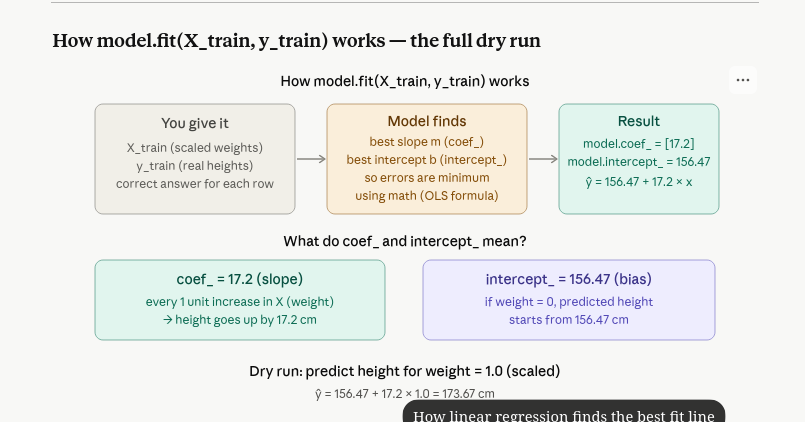

In [21]:
model.coef_ # coef == slope ( y = 0o + 01X) so Coef is 01

array([17.2982057])

In [22]:
print("Coefficent or Slope : ", model.coef_ )  
print("Intercept : ", model.intercept_)


# what Slope Mean: 
                #1 unit Movement in X ( Weight ) leads to 17.2 unit movement in y 

Coefficent or Slope :  [17.2982057]
Intercept :  156.47058823529412


___
# plot Best Fit Line 

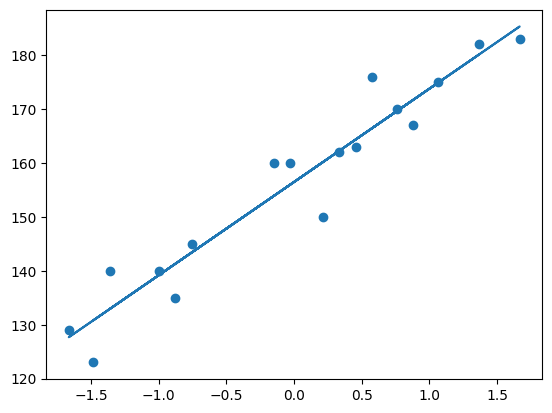

In [23]:
# plotting Training Data

plt.scatter(X_train,y_train)  # dots
plt.plot(X_train, model.predict(X_train)) # we  got best fit line

____

### Prediction for Test Data

   
    predicted Height Output = Intercept + Coef(Weights)

    y_pred_test = 156.47 + 17.2(X_test)
____

In [24]:
# Prediction for Test Data

y_predicted = model.predict(X_test)

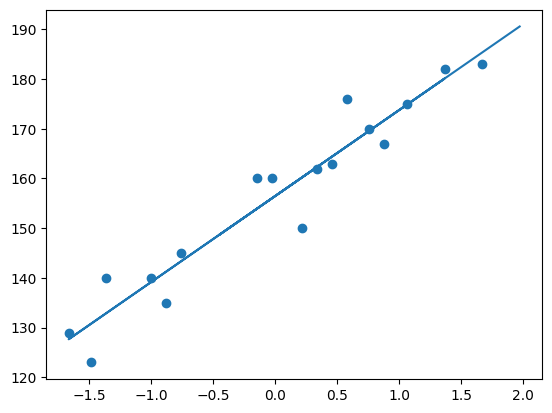

In [25]:
plt.scatter(X_train,y_train)
plt.plot(X_test, model.predict(X_test))

____

# Performance Metrics 
> see Notes in Linear regression Section



# Regression Evaluation Metrics

Regression metrics are used to measure how well a regression model predicts numerical values.

---

# 1. Mean Absolute Error (MAE)

MAE calculates the average absolute difference between the actual and predicted values.

## Formula

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

Where:

| Symbol      | Meaning           |
| ----------- | ----------------- |
| $y_i$       | Actual value      |
| $\hat{y}_i$ | Predicted value   |
| $n$         | Number of samples |

---

## Example

| Actual | Predicted | Error |
| ------ | --------- | ----- |
| 10     | 12        | 2     |
| 20     | 18        | 2     |
| 30     | 32        | 2     |

$$
MAE = \frac{2+2+2}{3}=2
$$

---

## Scikit-Learn Syntax

```python
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)
```

---

## Properties

* Easy to understand.
* Treats all errors equally.
* Less sensitive to outliers.

---

# 2. Mean Squared Error (MSE)

MSE calculates the average squared difference between actual and predicted values.

## Formula

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

---

## Example

| Actual | Predicted | Error | Squared Error |
| ------ | --------- | ----- | ------------- |
| 10     | 12        | 2     | 4             |
| 20     | 18        | 2     | 4             |
| 30     | 32        | 2     | 4             |

$$
MSE = \frac{4+4+4}{3}=4
$$

---

## Scikit-Learn Syntax

```python
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print(mse)
```

---

## Properties

* Penalizes large errors heavily.
* Sensitive to outliers.
* Commonly used as a cost function.

---

# 3. Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

## Formula

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

or simply:

$$
RMSE = \sqrt{MSE}
$$

---

## Example

If:

$$
MSE = 4
$$

then:

$$
RMSE = \sqrt{4}=2
$$

---

## Scikit-Learn Syntax

```python
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print(rmse)
```

### Older versions of Scikit-Learn

```python
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
```

---

# Comparison

| Metric | Formula                | Outlier Sensitive |
| ------ | ---------------------- | ----------------- |
| MAE    | Average absolute error | No                |
| MSE    | Average squared error  | Yes               |
| RMSE   | Square root of MSE     | Yes               |

---

# Rule of Thumb

* Use **MAE** when you want a robust and interpretable error measure.
* Use **MSE** when large errors should be penalized heavily.
* Use **RMSE** when you want the error in the original units of the target variable.

---

## One-Line Definitions

> **MAE:** Average absolute prediction error.

> **MSE:** Average squared prediction error.

> **RMSE:** Square root of the average squared prediction error.

___

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [27]:
mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
rmse = np.sqrt(mse)

print("MSE : ", mse)
print("MAE : ", mae)
print("RMSE : ", rmse)

MSE :  114.84069295228699
MAE :  9.66512588679501
RMSE :  10.716374991212605


___
___

# R² Score and Adjusted R² Score

R² (Coefficient of Determination) measures how much of the variation in the target variable is explained by the model.

---

# 1. R² Score

## Formula

$$ R^2 = 1 - \frac{ \sum_{i=1}^{n}(y_i-\hat{y}_i)^2 }{ \sum_{i=1}^{n}(y_i-\bar{y})^2 } $$


R^2 = 1 - SSR / SST

Where:

| Symbol      | Meaning               |
| ----------- | --------------------- |
| $y_i$       | Actual value          |
| $\hat{y}_i$ | Predicted value       |
| $\bar{y}$   | Mean of actual values |
| $n$         | Number of samples     |

---

## What Does It Measure?

R² compares:

* The error made by our model.
* The error made by simply predicting the mean.

It answers the question:

> How much of the variance in the target variable is explained by the model?

---

## Interpretation

| R² Value | Meaning                        |
| -------- | ------------------------------ |
| 1.0      | Perfect prediction             |
| 0.9      | Explains 90% of variance       |
| 0.5      | Explains 50% of variance       |
| 0        | Same as predicting the mean    |
| < 0      | Worse than predicting the mean |

---

## Example

Suppose:

```text id="p8j8wh"
Actual Marks:
80, 90, 100
```

If our model predicts almost perfectly:

```text id="6npf57"
79, 91, 99
```

Then:

$$
R^2 \approx 0.99
$$

Meaning:

> The model explains about 99% of the variation in the data.

---

## Scikit-Learn Syntax

```python id="dwttmo"
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)
```

---

## Another Way

```python id="x8gnk9"
model.score(X_test, y_test)
```

For regression models, `.score()` returns the R² score.

---

# Problem with R²

R² has one major problem:

> Adding more features almost always increases R², even if those features are useless.

Example:

```text id="9vdlzc"
House Price
    ↑
Features:
- Area
- Bedrooms
- Age
- Owner's Favorite Color
```

Even the useless feature may increase R² slightly.

---

# 2. Adjusted R²

Adjusted R² fixes this problem by penalizing unnecessary features.

---

## Formula

$$
Adjusted\ R^2
=============

1-
\left(
\frac{(1-R^2)(n-1)}
{n-p-1}
\right)
$$

Where:

| Symbol | Meaning            |
| ------ | ------------------ |
| $R^2$  | R² score           |
| $n$    | Number of samples  |
| $p$    | Number of features |

---

## Why Use Adjusted R²?

Adjusted R²:

* Increases only when a new feature improves the model significantly.
* Penalizes unnecessary features.
* Is especially useful in multiple linear regression.

---

## Example

Suppose:

| Features | R²   | Adjusted R² |
| -------- | ---- | ----------- |
| 2        | 0.85 | 0.84        |
| 5        | 0.86 | 0.82        |

Although R² increased:

```text id="rrk4m1"
0.85 → 0.86
```

Adjusted R² decreased:

```text id="agp6rk"
0.84 → 0.82
```

This indicates that the new features are probably not useful.

---

## Scikit-Learn Syntax

Scikit-Learn does not provide a built-in function for Adjusted R².

We calculate it manually:

```python id="j0wx9u"
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - p - 1)
)

print(adjusted_r2)
```

---

# Comparison

| Metric      | Penalizes Extra Features |
| ----------- | ------------------------ |
| R²          | No                       |
| Adjusted R² | Yes                      |

---

# Rule of Thumb

* For **Simple Linear Regression**, use **R²**.
* For **Multiple Linear Regression**, prefer **Adjusted R²**.

---

## One-Line Definitions

> **R² Score:** Percentage of variance in the target variable explained by the model.

> **Adjusted R² Score:** R² score adjusted for the number of features used in the model.


___
___

In [28]:
from sklearn.metrics import r2_score

In [29]:
score = r2_score(y_test, y_predicted)
print(score)

# model is 73 percent Accurate 

0.7360826717981276


____

# Adjusted R sq 
$$
Adjusted\ R^2
=============

1-
\left(
\frac{(1-R^2)(n-1)}
{n-p-1}
\right)
$$
___

In [30]:
from sklearn.metrics import r2_score

# Step 1: Normal R² calculate karo
r2 = r2_score(y_test, y_predicted)

# Step 2: n aur k nikaalo
n = X_test.shape[0]   # number of samples (rows)
k = X_test.shape[1]   # number of features (columns)

# Step 3: Adjusted R² formula apply karo
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"R² Score:          {r2:.4f}")
print(f"Adjusted R² Score: {adjusted_r2:.4f}")

R² Score:          0.7361
Adjusted R² Score: 0.6701
